<a href="https://colab.research.google.com/github/your-org/alexpose/blob/main/experiments/multiple-sclerosis/02_anatomical_mask_and_tokenization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 - The anatomical mask and tokenization

S-JEPA learns by hiding part of the skeleton and predicting the hidden part in feature space. Two design choices drive this notebook: **how we cut the skeleton into tokens**, and **which joints we hide**.

The original paper hides whichever joints move the most, a rule called motion-aware masking. For a gait study that is the wrong instinct, because in many conditions the telling sign is *less* motion: short steps, stiff knees, reduced arm swing. So we do something simpler and clinically grounded. We hide a **fixed set of neurologically relevant joints** and nothing else.


In [1]:
# --- Setup: install dependencies (Colab installs; local usually already has them) ---
import importlib, importlib.util, subprocess, sys, os

IN_COLAB = 'google.colab' in sys.modules

def _need(mod):
    return importlib.util.find_spec(mod) is None

# Light deps used by every notebook.
_pkgs = []
for mod, pip_name in [('cv2','opencv-python'), ('mediapipe','mediapipe'),
                      ('sklearn','scikit-learn'), ('pandas','pandas'),
                      ('matplotlib','matplotlib'), ('tqdm','tqdm')]:
    if _need(mod):
        _pkgs.append(pip_name)
if _pkgs:
    print('installing:', _pkgs)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *_pkgs])
else:
    print('all light dependencies already present')

all light dependencies already present


In [2]:
# --- Make `sjepa` and `ambient` importable, locally and in Colab ---
from pathlib import Path
import sys, subprocess

def _find_exp_dir():
    # Local run: this notebook sits in experiments/multiple-sclerosis.
    here = Path.cwd()
    for p in [here, *here.parents]:
        if (p / 'sjepa' / '__init__.py').exists():
            return p
    return None

EXP_DIR = _find_exp_dir()
if EXP_DIR is None:
    # Colab: clone the repo, then point at the experiment folder.
    REPO = 'https://github.com/your-org/alexpose.git'  # <-- edit to your fork
    if not Path('alexpose').exists():
        subprocess.check_call(['git', 'clone', '--depth', '1', REPO])
    EXP_DIR = Path('alexpose') / 'experiments' / 'multiple-sclerosis'

REPO_ROOT = EXP_DIR.parents[1]
for p in (str(EXP_DIR), str(REPO_ROOT)):
    if p not in sys.path:
        sys.path.insert(0, p)
print('experiment dir:', EXP_DIR)
print('repo root     :', REPO_ROOT)

experiment dir: /Users/pmui/dev/alexpose/experiments/multiple-sclerosis
repo root     : /Users/pmui/dev/alexpose


In [3]:
# --- Paths and profile (reads the root .env if python-dotenv is present) ---
import os
try:
    from dotenv import load_dotenv
    load_dotenv(REPO_ROOT / '.env')
except Exception:
    pass

VIDEO_DIR = EXP_DIR / 'video-data'
ARTIFACT_DIR = EXP_DIR / 'artifacts'
KEYPOINTS_DIR = ARTIFACT_DIR / 'keypoints'
IMAGES_DIR = EXP_DIR / 'images'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Pick the model size profile. 'laptop' is the fast default; set SJEPA_PROFILE=gpu
# in your .env for a larger model, or SJEPA_SMOKE=1 for a near-instant test run.
os.environ.setdefault('SJEPA_PROFILE', 'laptop')
print('SJEPA_PROFILE =', os.environ['SJEPA_PROFILE'],
      '| SJEPA_SMOKE =', os.environ.get('SJEPA_SMOKE', '0'))

SJEPA_PROFILE = laptop | SJEPA_SMOKE = 0


## Tokenizing a window

A training window is a short movie of stick figures. We group `l = 4` adjacent frames of one joint into a single token, so each token summarizes how that joint moved over a moment. With 32 frames and 33 joints that gives `(32 / 4) x 33 = 264` tokens.


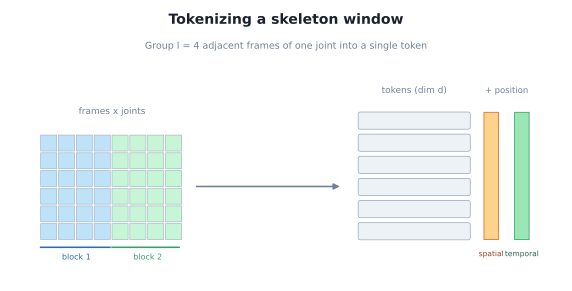

In [4]:
from IPython.display import SVG, display
display(SVG(filename=str(IMAGES_DIR / 'tokenization.svg')))

In [5]:
from sjepa.config import get_config, describe
cfg = get_config()  # honours SJEPA_PROFILE
print(describe(cfg))
print('tokens per window N =', cfg.num_tokens,
      f'= {cfg.num_time_tokens} time blocks x {cfg.num_joints} joints')

profile=laptop | window=32f @ 15fps | tokens N=264 (8 time x 33 joints) | encoder 3L x 96d x 4h | predictor 2L x 96d | pretrain 40ep, finetune 30ep
tokens per window N = 264 = 8 time blocks x 33 joints


## The fixed anatomical mask

The file `mapping-data/ms-pd-mapping.md` lists the joints clinicians care about for ms and pd. After removing duplicates and sorting, we get exactly twelve BlazePose landmarks: both shoulders and both complete legs. These are the joints we hide and ask the model to predict. No other joints are ever masked.


In [6]:
from sjepa.masking import MASKED_JOINTS, AnatomicalMaskSampler, masked_joint_names
from ambient.pose.keypoint_data import MEDIAPIPE_33_NAMES
import pandas as pd

# The features from the mapping file that each masked joint supports.
features_for = {
    11: 'shoulder_symmetry_index, trunk_lean_angle',
    12: 'shoulder_symmetry_index, trunk_lean_angle',
    23: 'walking_speed_ms, hip_asymmetry, knee_range, trunk_lean_angle',
    24: 'walking_speed_ms, hip_asymmetry, knee_range, trunk_lean_angle',
    25: 'knee_range, ankle_range', 26: 'knee_range, ankle_range',
    27: 'knee_range, ankle_range, step_width_m', 28: 'knee_range, ankle_range, step_width_m',
    29: 'stride_length_m, double_support_pct, stride_time_cv, ankle_range',
    30: 'stride_length_m, double_support_pct, stride_time_cv, ankle_range',
    31: 'stride_length_m, double_support_pct, stride_time_cv, ankle_range',
    32: 'stride_length_m, double_support_pct, stride_time_cv, ankle_range',
}
table = pd.DataFrame([
    {'BLAZEPOSE_33 index': j, 'Keypoint name': MEDIAPIPE_33_NAMES[j],
     'Features involved': features_for[j]}
    for j in MASKED_JOINTS
])
table

,BLAZEPOSE_33 index,Keypoint name,Features involved
0,11,LEFT_SHOULDER,"shoulder_symmetry_index, trunk_lean_angle"
1,12,RIGHT_SHOULDER,"shoulder_symmetry_index, trunk_lean_angle"
2,23,LEFT_HIP,"walking_speed_ms, hip_asymmetry, knee_range, t..."
3,24,RIGHT_HIP,"walking_speed_ms, hip_asymmetry, knee_range, t..."
4,25,LEFT_KNEE,"knee_range, ankle_range"
5,26,RIGHT_KNEE,"knee_range, ankle_range"
6,27,LEFT_ANKLE,"knee_range, ankle_range, step_width_m"
7,28,RIGHT_ANKLE,"knee_range, ankle_range, step_width_m"
8,29,LEFT_HEEL,"stride_length_m, double_support_pct, stride_ti..."
9,30,RIGHT_HEEL,"stride_length_m, double_support_pct, stride_ti..."


That table is the whole masking rule. Twelve joints, chosen once, used every step. Here is the same set drawn on the skeleton.


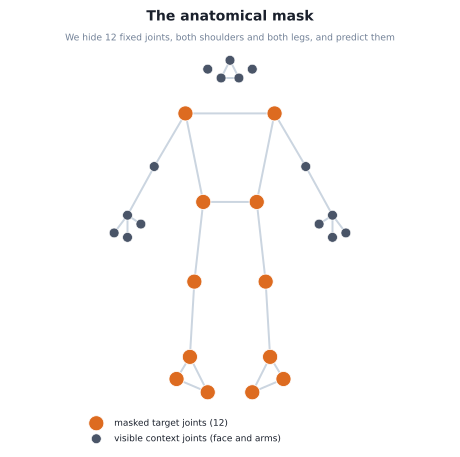

In [7]:
display(SVG(filename=str(IMAGES_DIR / 'anatomical_mask.svg')))

## The mask on a real skeleton

The animation below highlights the masked joints in red on one real walking sequence. Those red joints are what the model must reconstruct from the rest.


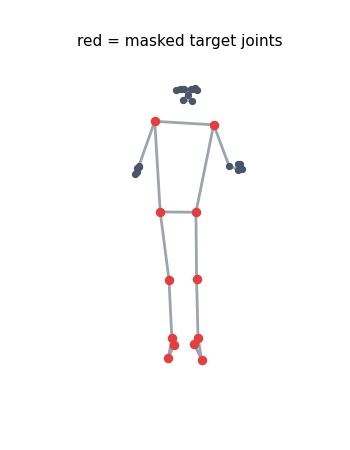

In [8]:
from sjepa.data import load_index
from sjepa.viz import skeleton_animation
from IPython.display import Image

recs = load_index(KEYPOINTS_DIR)
seq = recs[0].load_norm()
gif = skeleton_animation(seq, ARTIFACT_DIR / 'mask_demo.gif',
                         masked_joints=list(MASKED_JOINTS), fps=15,
                         title='red = masked target joints')
Image(filename=str(gif))

## How the mask becomes tokens

The mask sampler turns those twelve joints into a boolean over the 264 tokens: every time block of a masked joint is a target token, everything else is visible context. It takes no motion input, so the split is identical for every clip.


In [9]:
sampler = AnatomicalMaskSampler(cfg.num_joints, cfg.num_time_tokens)
print(sampler.summary())
tm, cm = sampler.target_mask, sampler.context_mask
assert not (tm & cm).any() and (tm | cm).all()  # no overlap, full cover
print('target tokens:', int(tm.sum()), '| context tokens:', int(cm.sum()))
print('This is what replaces motion-aware masking. Fixed, clinical, and simple.')

AnatomicalMaskSampler: 96 target tokens, 168 context tokens (masked joints=[11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32])
target tokens: 96 | context tokens: 168
This is what replaces motion-aware masking. Fixed, clinical, and simple.
